# Detecção de Pneumonia em Raio-X com CNN (Rede neural convolucional)

## Objetivo
Construir um modelo de Deep Learning capaz de classificar imagens
de raio-X de tórax em Normal ou Pneumonia.

## Bibliotecas utilizadas
- Python
- TensorFlow / Keras
- OpenCV
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

## Instalando e importando bibliotecas

In [ ]:
!pip install tensorflow
!pip install opencv-python

In [ ]:
import json
import os
import random
import shutil
from pathlib import Path
import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def processa_imagem_tl(caminho_imagem):
  """
  Pré-processamento adaptado para Transfer Learning.
  - Escala de cinza → 3 canais (pseudo-RGB)
  - Redimensionamento para 224x224 (padrão ImageNet)
  - CLAHE + normalização [0, 1]
  """
  imagens = []
  rotulos = []
  arquivos = [os.path.join(caminho_imagem, img) for img in os.listdir(caminho_imagem)]
  for i in arquivos:
    img = cv2.imread(i, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = img.astype("float32") / 255.0
    # Empilhar em 3 canais para compatibilidade com modelos pré-treinados
    img = np.stack([img, img, img], axis=-1)
    imagens.append(img)
    rotulos.append(1 if "PNEUMONIA" in i else 0)
  return np.array(imagens), np.array(rotulos)


In [ ]:
caminho = "/content/drive/MyDrive/treino"
imagens_tl, rotulos_tl = processa_imagem_tl(caminho)
print(f"Shape das imagens: {imagens_tl.shape}")
print(f"Shape dos rótulos: {rotulos_tl.shape}")

# Split com stratify
x_treino_tl, x_temp_tl, y_treino_tl, y_temp_tl = train_test_split(
    imagens_tl, rotulos_tl, test_size=0.3, random_state=42, stratify=rotulos_tl
)
x_val_tl, x_teste_tl, y_val_tl, y_teste_tl = train_test_split(
    x_temp_tl, y_temp_tl, test_size=0.5, random_state=42, stratify=y_temp_tl
)

print(f"\nDistribuição treino  - Normal: {np.sum(y_treino_tl==0)}, Pneumonia: {np.sum(y_treino_tl==1)}")
print(f"Distribuição valid   - Normal: {np.sum(y_val_tl==0)}, Pneumonia: {np.sum(y_val_tl==1)}")
print(f"Distribuição teste   - Normal: {np.sum(y_teste_tl==0)}, Pneumonia: {np.sum(y_teste_tl==1)}")


Shape das imagens: (5910, 128, 128, 3)
Shape dos rótulos: (5910,)

Distribuição treino  - Normal: 1956, Pneumonia: 2181
Distribuição valid   - Normal: 419, Pneumonia: 467
Distribuição teste   - Normal: 420, Pneumonia: 467


In [ ]:
from tensorflow.keras.applications import MobileNetV2

# Base pré-treinada (congelada)
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Modelo completo
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

model_tl.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

Epoch 1/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 253ms/step - accuracy: 0.9101 - auc: 0.9694 - loss: 0.2250 - precision: 0.9225 - recall: 0.9055 - val_accuracy: 0.9312 - val_auc: 0.9832 - val_loss: 0.1688 - val_precision: 0.9194 - val_recall: 0.9529 - learning_rate: 0.0010
Epoch 2/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.9405 - auc: 0.9860 - loss: 0.1503 - precision: 0.9452 - recall: 0.9418 - val_accuracy: 0.9503 - val_auc: 0.9890 - val_loss: 0.1403 - val_precision: 0.9325 - val_recall: 0.9764 - learning_rate: 0.0010
Epoch 3/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9500 - auc: 0.9893 - loss: 0.1285 - precision: 0.9582 - recall: 0.9464 - val_accuracy: 0.9447 - val_auc: 0.9898 - val_loss: 0.1513 - val_precision: 0.9197 - val_recall: 0.9807 - learning_rate: 0.0010
Epoch 4/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9560 - auc: 0.9929 - loss: 0.1087 - precision: 0.9574 - recall: 0.9592 - val_accuracy: 0.9312 - val_auc: 0.9907 - val_loss: 0.154

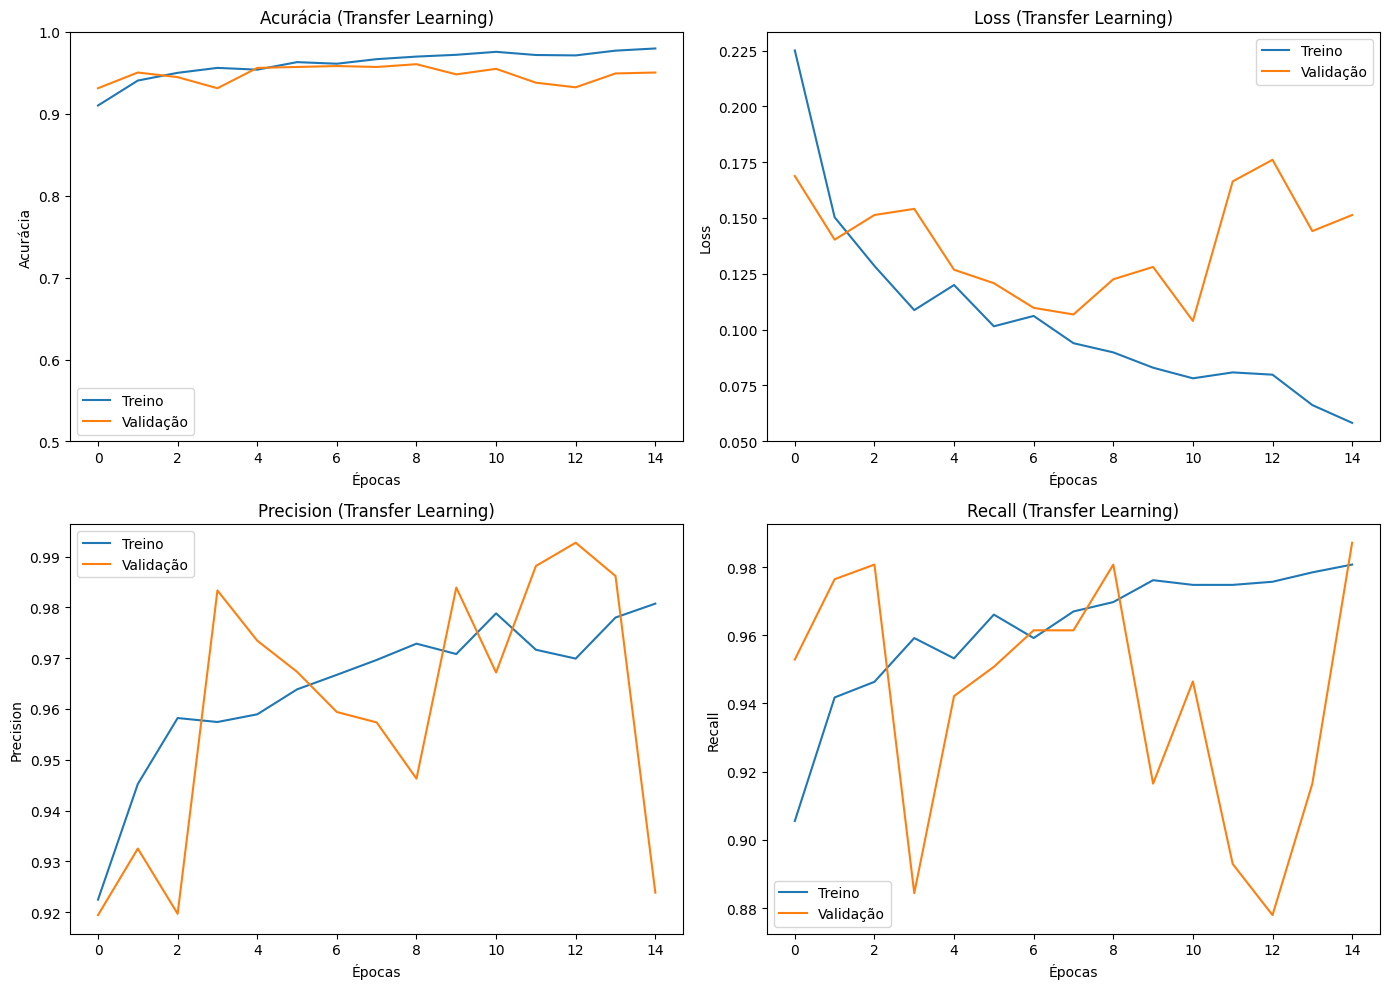


AVALIAÇÃO NO CONJUNTO DE TESTE (TRANSFER LEARNING)
28/28 - 12s - 421ms/step - accuracy: 0.9572 - auc: 0.9936 - loss: 0.1122 - precision: 0.9908 - recall: 0.9272
loss: 0.1122
compile_metrics: 0.9572


In [ ]:
early_stop_tl = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_tl = model_tl.fit(
    x_treino_tl, y_treino_tl,
    epochs=15,
    validation_data=(x_val_tl, y_val_tl),
    callbacks=[early_stop_tl, reduce_lr_tl]
)

# Gráficos de treinamento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history_tl.history['accuracy'], label='Treino')
axes[0, 0].plot(history_tl.history['val_accuracy'], label='Validação')
axes[0, 0].set_title('Acurácia (Transfer Learning)')
axes[0, 0].set_xlabel('Épocas')
axes[0, 0].set_ylabel('Acurácia')
axes[0, 0].legend()
axes[0, 0].set_ylim([0.5, 1])

axes[0, 1].plot(history_tl.history['loss'], label='Treino')
axes[0, 1].plot(history_tl.history['val_loss'], label='Validação')
axes[0, 1].set_title('Loss (Transfer Learning)')
axes[0, 1].set_xlabel('Épocas')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

axes[1, 0].plot(history_tl.history['precision'], label='Treino')
axes[1, 0].plot(history_tl.history['val_precision'], label='Validação')
axes[1, 0].set_title('Precision (Transfer Learning)')
axes[1, 0].set_xlabel('Épocas')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()

axes[1, 1].plot(history_tl.history['recall'], label='Treino')
axes[1, 1].plot(history_tl.history['val_recall'], label='Validação')
axes[1, 1].set_title('Recall (Transfer Learning)')
axes[1, 1].set_xlabel('Épocas')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Avaliação no conjunto de teste interno
print("\n" + "="*50)
print("AVALIAÇÃO NO CONJUNTO DE TESTE (TRANSFER LEARNING)")
print("="*50)
resultados_tl = model_tl.evaluate(x_teste_tl, y_teste_tl, verbose=2)
for nome, valor in zip(model_tl.metrics_names, resultados_tl):
    print(f'{nome}: {valor:.4f}')


In [ ]:
def predicar_tl(caminho):
  """Predição de uma única imagem usando o modelo Transfer Learning."""
  img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(img, (128, 128))
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
  img = clahe.apply(img)
  img = img.astype("float32") / 255.0
  img = np.stack([img, img, img], axis=-1)
  img = np.expand_dims(img, axis=0)
  pred = model_tl.predict(img, verbose=0)
  classe = int(pred[0][0] > 0.5)
  return classe


In [ ]:
def predizer_pasta(caminho_pasta, predicar):
    y_real = []
    y_pred = []

    nome_arquivo = os.listdir(caminho_pasta)

    for imagem in sorted(nome_arquivo):
        caminho_inteiro = os.path.join(caminho_pasta, imagem)
        prediz = predicar(caminho_inteiro)
        y_pred.append(prediz)

        if 'NORMAL' in imagem:
            y_real.append(0)
        else:
            y_real.append(1)

    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    print("\n" + "="*50)
    print("RELATÓRIO DE CLASSIFICAÇÃO")
    print("="*50)
    print(classification_report(y_real, y_pred, target_names=['Normal', 'Pneumonia']))

    if len(np.unique(y_real)) > 1:
        auc = roc_auc_score(y_real, y_pred)
        print(f'AUC-ROC: {auc:.4f}')

    acuracia = np.mean(y_real == y_pred)
    print(f'Acurácia geral: {acuracia:.4f}')

    cm = confusion_matrix(y_real, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f'\nVerdadeiro Negativo (Normal correto): {tn}')
    print(f'Verdadeiro Positivo (Pneumonia correto): {tp}')
    print(f'Falso Positivo (Normal → Pneumonia): {fp}')
    print(f'Falso Negativo (Pneumonia → Normal): {fn}')

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'])
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.title('Matriz de Confusão')
    plt.tight_layout()
    plt.show()


AVALIAÇÃO TRANSFER LEARNING - Dataset Kaggle test

RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

      Normal       0.90      0.74      0.81       234
   Pneumonia       0.86      0.95      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.84      0.86       624
weighted avg       0.87      0.87      0.87       624

AUC-ROC: 0.8440
Acurácia geral: 0.8702

Verdadeiro Negativo (Normal correto): 173
Verdadeiro Positivo (Pneumonia correto): 370
Falso Positivo (Normal → Pneumonia): 61
Falso Negativo (Pneumonia → Normal): 20


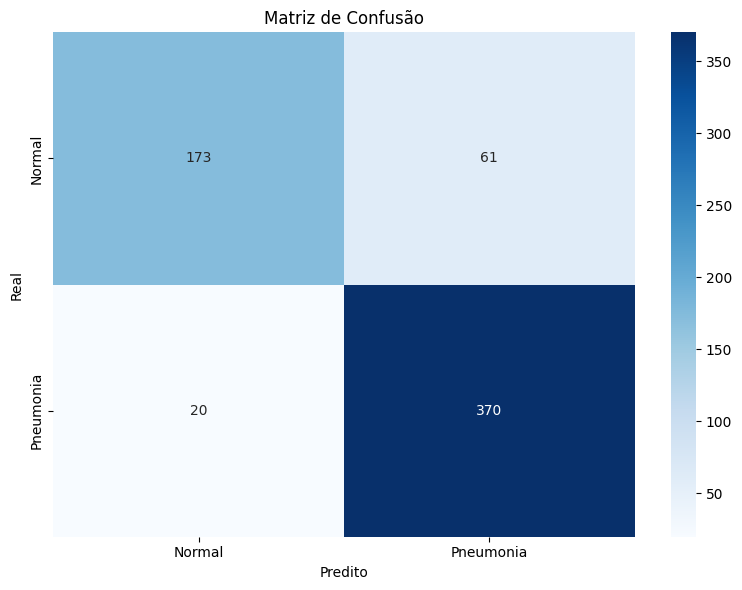

In [ ]:
print("=" * 60)
print("AVALIAÇÃO TRANSFER LEARNING - Dataset Kaggle test")
print("=" * 60)
predizer_pasta("/content/drive/MyDrive/kaggle/test", predicar_tl)


AVALIAÇÃO TRANSFER LEARNING - Dataset Kaggle train

RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

      Normal       0.83      0.98      0.90      1341
   Pneumonia       0.99      0.93      0.96      3875

    accuracy                           0.94      5216
   macro avg       0.91      0.96      0.93      5216
weighted avg       0.95      0.94      0.95      5216

AUC-ROC: 0.9562
Acurácia geral: 0.9440

Verdadeiro Negativo (Normal correto): 1316
Verdadeiro Positivo (Pneumonia correto): 3608
Falso Positivo (Normal → Pneumonia): 25
Falso Negativo (Pneumonia → Normal): 267


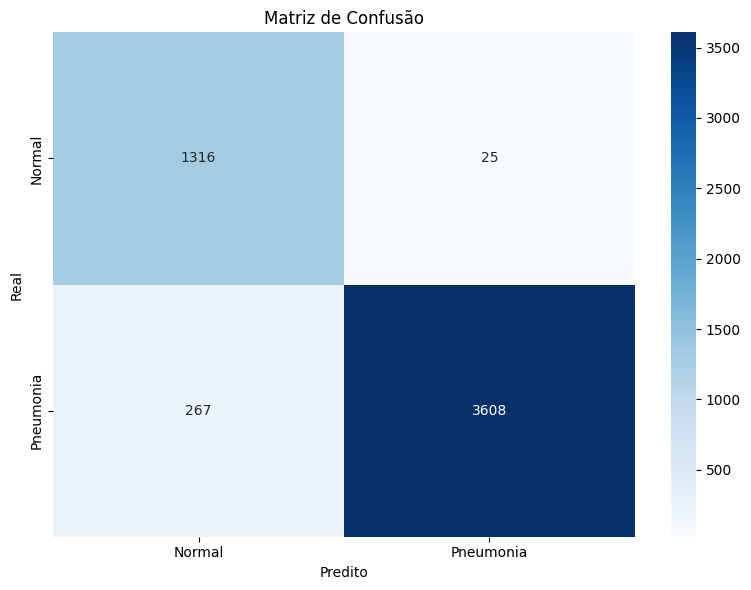

In [ ]:
print("=" * 60)
print("AVALIAÇÃO TRANSFER LEARNING - Dataset Kaggle train")
print("=" * 60)
predizer_pasta('/content/drive/MyDrive/kaggle/train', predicar_tl)
